# SST Upwelling Binary Segmentation Pooled (2010 - 2019)
Generates aggregate violin plots pooling data across all years (2010–2019) for CDOM partitions (Upwelling vs Non-upwelling) by Month.
Includes a multi-panel figure for CDOM S275:295, S300:600, a(412), and Log10 Chlorophyll.

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings

# 1. Load the data
file_path = r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl'
try:
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    df = data['data']
    print("Data loaded successfully.")
    
    # Ensure datetime index is parsed
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
        
except FileNotFoundError:
    print("Data file not found. Please check path.")

Data loaded successfully.


In [3]:
def extract_year_data(year, df):
    year_str = str(year)
    print(f"Extracting Year: {year_str}")
    
    if int(year) not in df.index.year.unique():
        return None
        
    df_year = df[df.index.year == int(year)].copy()
    monthly_binary = {}
    
    # 1. Compute monthly means and their binary upwelling threshold 
    for m in range(1, 13):
        month_rows = df_year[df_year.index.month == m]
        month_grids = []
        for _, row in month_rows.iterrows():
            grid = row.get('sst')
            if grid is not None and not (isinstance(grid, float) and np.isnan(grid)):
                month_grids.append(np.array(grid, dtype=float))
                
        if month_grids:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', category=RuntimeWarning)
                mean_month_sst = np.nanmean(np.stack(month_grids), axis=0)
                
            spatial_mean = np.nanmean(mean_month_sst)
            spatial_std = np.nanstd(mean_month_sst)
            threshold = spatial_mean - spatial_std
            
            binary_grid = np.zeros_like(mean_month_sst)
            binary_grid[mean_month_sst <= threshold] = 1
            binary_grid[np.isnan(mean_month_sst)] = np.nan
            monthly_binary[m] = binary_grid
        else:
            monthly_binary[m] = None

    # 2. Extract CDOM daily pixels
    all_month_labels = []
    all_month_is_upwelling = []
    all_month_s275 = []
    all_month_s300 = []
    all_month_a412 = []
    
    all_month_chlor_labels = []
    all_month_chlor_is_upwelling = []
    all_month_chlor = []

    def _is_missing_grid(grid_obj):
        return grid_obj is None or (isinstance(grid_obj, float) and np.isnan(grid_obj))

    for m in range(1, 13):
        bin_grid = monthly_binary.get(m)
        if bin_grid is None or isinstance(bin_grid, float):
            continue
            
        bin_flat = bin_grid.flatten()
        month_rows = df_year[df_year.index.month == m]
        
        for _, row in month_rows.iterrows():
            s275 = row.get('cdom_slope_275_295')
            s300 = row.get('cdom_slope_300_600')
            a412 = row.get('cdom_412', row.get('cdom'))
            chlor = row.get('chlorophyll', row.get('chlor_a'))
            
            # --- Extract CDOM ---
            if not any(_is_missing_grid(g) for g in [s275, s300, a412]):
                s275_flat = np.array(s275, dtype=float).flatten()
                s300_flat = np.array(s300, dtype=float).flatten()
                a412_flat = np.array(a412, dtype=float).flatten()
                
                valid_cdom = (
                    ~np.isnan(bin_flat) & 
                    ~np.isnan(s275_flat) & 
                    ~np.isnan(s300_flat) & 
                    ~np.isnan(a412_flat) &
                    (a412_flat > 0)
                )
                
                if np.any(valid_cdom):
                    up_flags = bin_flat[valid_cdom] == 1
                    all_month_labels.extend([m] * int(np.sum(valid_cdom)))
                    all_month_is_upwelling.extend(up_flags)
                    all_month_s275.extend(s275_flat[valid_cdom])
                    all_month_s300.extend(s300_flat[valid_cdom])
                    all_month_a412.extend(a412_flat[valid_cdom])

            # --- Extract Chlorophyll ---
            if not _is_missing_grid(chlor):
                chlor_flat = np.array(chlor, dtype=float).flatten()
                
                valid_chlor = (
                    ~np.isnan(bin_flat) & 
                    ~np.isnan(chlor_flat) &
                    (chlor_flat > 0)
                )
                
                if np.any(valid_chlor):
                    up_flags_chlor = bin_flat[valid_chlor] == 1
                    all_month_chlor_labels.extend([m] * int(np.sum(valid_chlor)))
                    all_month_chlor_is_upwelling.extend(up_flags_chlor)
                    all_month_chlor.extend(np.log10(chlor_flat[valid_chlor]))

    all_month_labels = np.array(all_month_labels, dtype=int)
    all_month_is_upwelling = np.array(all_month_is_upwelling, dtype=bool)
    all_month_s275 = np.array(all_month_s275)
    all_month_s300 = np.array(all_month_s300)
    all_month_a412 = np.array(all_month_a412)
    
    all_month_chlor_labels = np.array(all_month_chlor_labels, dtype=int)
    all_month_chlor_is_upwelling = np.array(all_month_chlor_is_upwelling, dtype=bool)
    all_month_chlor = np.array(all_month_chlor)

    if all_month_labels.size == 0 and all_month_chlor.size == 0:
        return None

    return {
        'labels': all_month_labels,
        'is_upwelling': all_month_is_upwelling,
        's275': all_month_s275,
        's300': all_month_s300,
        'a412': all_month_a412,
        'chlor_labels': all_month_chlor_labels,
        'chlor_is_upwelling': all_month_chlor_is_upwelling,
        'chlor': all_month_chlor
    }

In [4]:
# 1. Extract and pool data for all years
pooled_data = {
    'labels': [], 'is_upwelling': [], 's275': [], 's300': [], 'a412': [],
    'chlor_labels': [], 'chlor_is_upwelling': [], 'chlor': []
}

for year in range(2010, 2020):
    yd = extract_year_data(year, df)
    if yd:
        pooled_data['labels'].append(yd['labels'])
        pooled_data['is_upwelling'].append(yd['is_upwelling'])
        pooled_data['s275'].append(yd['s275'])
        pooled_data['s300'].append(yd['s300'])
        pooled_data['a412'].append(yd['a412'])
        
        pooled_data['chlor_labels'].append(yd['chlor_labels'])
        pooled_data['chlor_is_upwelling'].append(yd['chlor_is_upwelling'])
        pooled_data['chlor'].append(yd['chlor'])

# Concatenate arrays
for k in pooled_data:
    pooled_data[k] = np.concatenate(pooled_data[k])

print(f"Pooled CDOM points: {len(pooled_data['labels'])}")
print(f"Pooled Chlorophyll points: {len(pooled_data['chlor_labels'])}")

Extracting Year: 2010
Extracting Year: 2011
Extracting Year: 2012
Extracting Year: 2013
Extracting Year: 2014
Extracting Year: 2015
Extracting Year: 2016
Extracting Year: 2017
Extracting Year: 2018
Extracting Year: 2019
Pooled CDOM points: 35282774
Pooled Chlorophyll points: 60419911


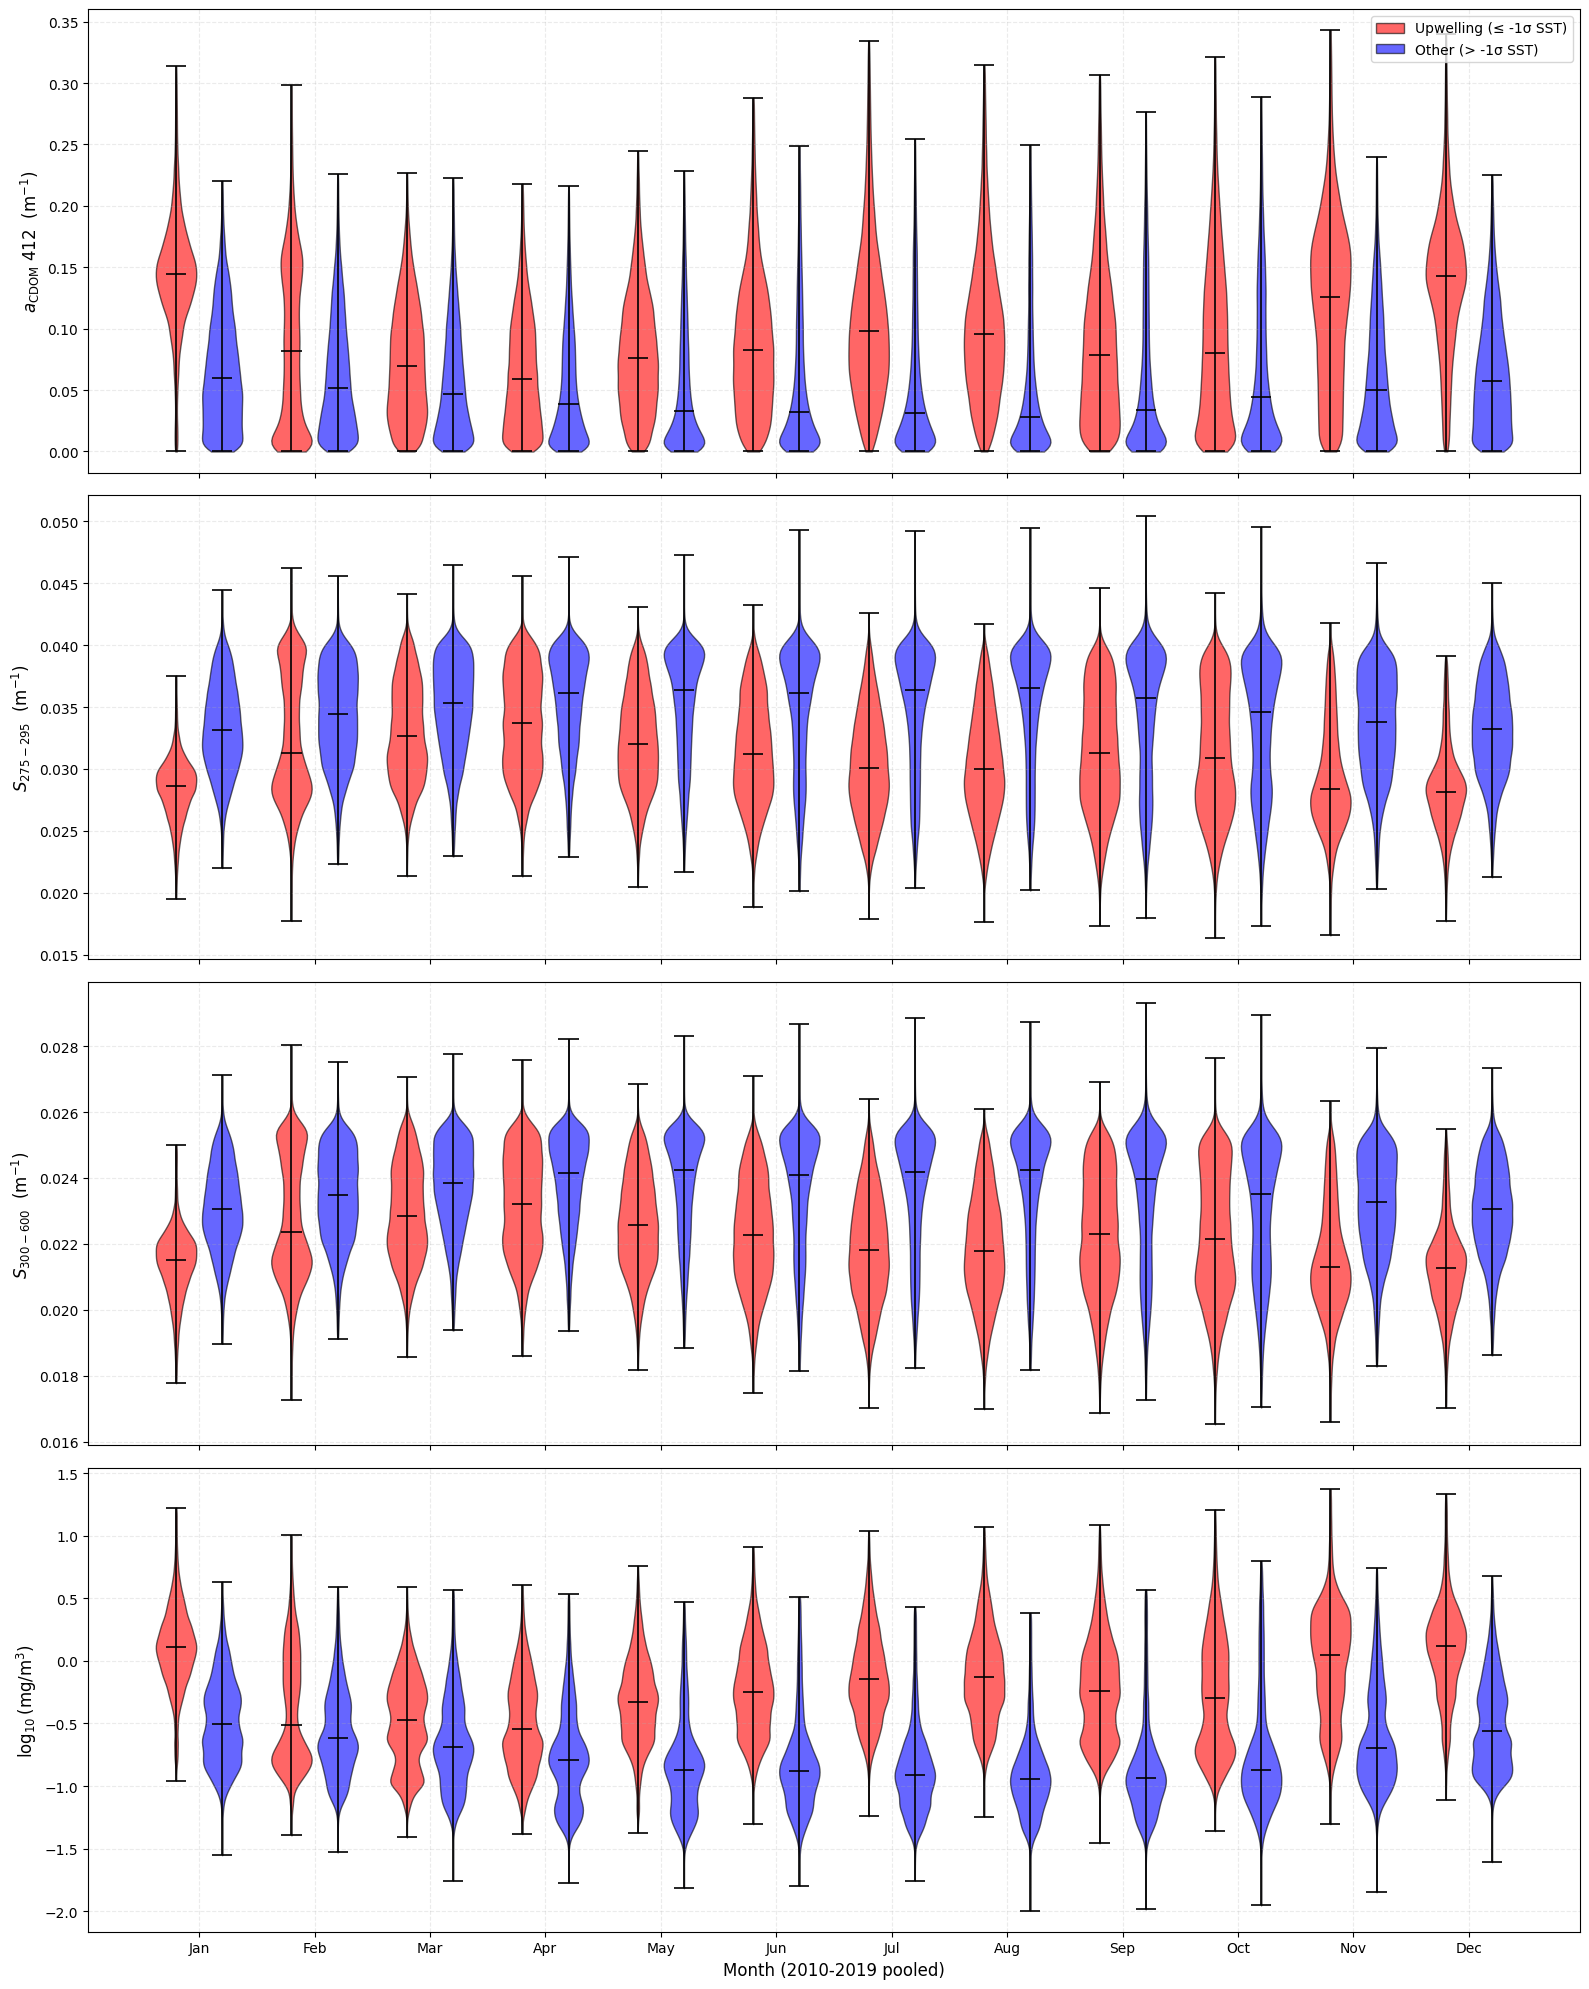

In [7]:
def add_violin_to_ax(ax, values, labels, is_upwelling, var_title, y_unit):
    up_data, non_data = [], []
    up_positions, non_positions = [], []
    
    for month in range(1, 13):
        month_mask = labels == month
        up_vals = values[month_mask & (is_upwelling == True)]
        non_vals = values[month_mask & (is_upwelling == False)]
        
        up_vals = up_vals[~np.isnan(up_vals)]
        non_vals = non_vals[~np.isnan(non_vals)]
        
        # Trim outer 3 standard deviations
        if up_vals.size > 1:
            up_mean, up_std = np.mean(up_vals), np.std(up_vals)
            up_vals = up_vals[(up_vals >= up_mean - 3 * up_std) & (up_vals <= up_mean + 3 * up_std)]
            # Subsample for faster plotting if huge
            if up_vals.size > 50000:
                up_vals = np.random.choice(up_vals, 50000, replace=False)
            
        if non_vals.size > 1:
            non_mean, non_std = np.mean(non_vals), np.std(non_vals)
            non_vals = non_vals[(non_vals >= non_mean - 3 * non_std) & (non_vals <= non_mean + 3 * non_std)]
            # Subsample for faster plotting if huge
            if non_vals.size > 50000:
                non_vals = np.random.choice(non_vals, 50000, replace=False)

        center = month
        
        if up_vals.size > 1:
            up_data.append(up_vals)
            up_positions.append(center - 0.2)
        if non_vals.size > 1:
            non_data.append(non_vals)
            non_positions.append(center + 0.2)
            
    if up_data:
        vp_up = ax.violinplot(up_data, positions=up_positions, widths=0.35, showmeans=False, showmedians=True, showextrema=True)
        for pc in vp_up['bodies']:
            pc.set_facecolor('red'); pc.set_edgecolor('black'); pc.set_alpha(0.60)
        for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            vp_up[partname].set_edgecolor('black'); vp_up[partname].set_linewidth(1.2)

    if non_data:
        vp_non = ax.violinplot(non_data, positions=non_positions, widths=0.35, showmeans=False, showmedians=True, showextrema=True)
        for pc in vp_non['bodies']:
            pc.set_facecolor('blue'); pc.set_edgecolor('black'); pc.set_alpha(0.60)
        for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
            vp_non[partname].set_edgecolor('black'); vp_non[partname].set_linewidth(1.2)

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.set_ylabel(f"{y_unit}", fontsize=12)
    ax.grid(True, alpha=0.25, linestyle='--')

# Create Multi-panel figure
fig, axes = plt.subplots(4, 1, figsize=(16, 20), sharex=True)

# Panel 1: a(412)
add_violin_to_ax(axes[0], pooled_data['a412'], pooled_data['labels'], pooled_data['is_upwelling'], 'CDOM a(412)', r'$a_{\text{CDOM}}$ 412 $\text{ (m}^{-1}\text{)}$')

# Panel 2: S275:295
add_violin_to_ax(axes[1], pooled_data['s275'], pooled_data['labels'], pooled_data['is_upwelling'], 'CDOM S275:295', r'$S_{275-295}$ $\text{ (m}^{-1}\text{)}$')

# Panel 3: S300:600
add_violin_to_ax(axes[2], pooled_data['s300'], pooled_data['labels'], pooled_data['is_upwelling'], 'CDOM S300:600', r'$S_{300-600}$ $\text{ (m}^{-1}\text{)}$')

# Panel 4: Chlorophyll
add_violin_to_ax(axes[3], pooled_data['chlor'], pooled_data['chlor_labels'], pooled_data['chlor_is_upwelling'], 'Log10 Chlorophyll', r'$\log_{10}(\text{mg/m}^3)$')

# axes[0].set_title('Pooled Data (2010-2019): Upwelling vs Non-Upwelling by Month', fontsize=16, fontweight='bold')
axes[3].set_xlabel('Month (2010-2019 pooled)', fontsize=12)

legend_handles = [
    Patch(facecolor='red', edgecolor='black', alpha=0.60, label='Upwelling (≤ -1σ SST)'),
    Patch(facecolor='blue', edgecolor='black', alpha=0.60, label='Other (> -1σ SST)'),
]
axes[0].legend(handles=legend_handles, loc='upper right')

plt.tight_layout()
plt.show(block=False)

os.makedirs('figures', exist_ok=True)
fig.savefig(os.path.join('figures', 'pooled_violin_all_years.png'), bbox_inches='tight', dpi=300)